# Imports 

In [1]:
import os
import re
import csv
import zipfile

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from sklearn.model_selection import (
    StratifiedKFold,
    train_test_split,
    KFold,
    cross_val_score,
)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    roc_curve,
    auc,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.tree import DecisionTreeClassifier

# Functions

# Datasets

In [2]:
path = "../../Data_Processing/outputs"

In [3]:
df = pd.concat(
    [
        pd.read_pickle(os.path.join(path, file))
        for file in os.listdir(path)
        if "df_banks_part_" in file
    ],
    axis=0,
).reset_index(drop=True)

In [4]:
df.head()

,id,country,legal_name,quarter,REVENUE_FRY9C,REVENUE_FRY9SP,REVENUE_FRY9LP,NET_INCOME_FRY9C,NET_INCOME_FRY9SP,NET_INCOME_FRY9LP,...,RECOVERIES_FARMERS_FRY9C,RECOVERIES_COMMERCE_INDUSTRY_FRY9C,RECOVERIES_HOUSEHOLDS_FRY9C,RECOVERIES_FOREIGN_GOV_FRY9C,RECOVERIES_LEASE_FINANCING_FRY9C,RATIO_CAPITAL_CONSERVATION_BUFFER_FRY9C,RATIO_TIER_1_LEVERAGE_FRY9C,RATIO_TOTAL_CAPITAL_FRY9C,RATIO_TIER_1_CAPITAL_FRY9C,RATIO_COMMON_EQUITY_TIER1_CAPITAL_FRY9C
0,1020201,UNITED STATES,HSBC USA INC.,20250630,0.0,0.0,432366.0,0.0,0.0,449067.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1020395,UNITED STATES,SOUTHERN NATIONAL CORPORATION,20250630,0.0,4913.0,0.0,0.0,6956.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1020582,UNITED STATES,WOODTRUST FINANCIAL CORPORATION,20250630,0.0,3889.0,0.0,0.0,12123.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1020676,UNITED STATES,AMALGAMATED INVESTMENTS COMPANY,20250630,0.0,1237.0,0.0,0.0,4954.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1020854,UNITED STATES,"BANK MANAGEMENT, INC.",20250630,0.0,0.0,0.0,0.0,3799.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
df_cols = pd.Series(df.columns)

In [6]:
# target variable:
#   reduction in revenue
#   reduction in net income
#   reduction in assets

# Adjust columns

## Metadata

In [7]:
df["year"] = df["quarter"].str[:4].astype(int)
df["month"] = df["quarter"].str[4:6].astype(int)
df["nr_quarter"] = ((df["month"] - 1) // 3) + 1

## Cummulative to per quarter features

Based on the reviewed documentation, we identified that the reported income statement figures (e.g., revenue, costs, profit) represent year-to-date values for each fiscal year. This means that each quarter’s figures are cumulative for that year, resetting at the beginning of the first quarter.

In contrast, the balance sheet figures (e.g., assets, liabilities, equity) reflect the position at the end of each quarter and do not reset at the start of the year.

Therefore, for income statement data, we chose to estimate the quarterly contribution to eliminate the seasonality effect caused by the reset in the first quarter of each year.


Sources:
- FR Y -9c 
    - financial statement: https://www.federalreserve.gov/reportforms/forms/FR_Y-9C20180930_f.pdf
    - detail on financial statement rubrics: https://www.federalreserve.gov/apps/reportingforms/Download/DownloadAttachment?guid=d036ea09-75d3-4f2f-8fe3-0f43c76d2f70

- FR_Y-9LP (Parent Company Only Financial Statements for Large Bank Holding Companies): 
    - financial statement: https://www.federalreserve.gov/apps/reportingforms/Download/DownloadAttachment?guid=e56cd829-8369-4263-96ca-4de4e12ce585#:~:text=03/2024-,For%20Federal%20Reserve%20Bank%20Use%20Only,for%20investments%20in%20equity%20securities.
    - detail on financial statement rubrics: https://www.federalreserve.gov/reportforms/forms/FR_Y-9LP20220705_i.pdf 

- FR Y-9SP (Parent Company Only Financial Statements for Small Holding Companies) - only reports data semi-annually 
    - financial statement: https://www.federalreserve.gov/apps/reportingforms/Download/DownloadAttachment?guid=9df5bb23-468c-4407-a874-7beaba03b930
    - detail on financial statement rubrics: https://www.federalreserve.gov/apps/reportingforms/Download/DownloadAttachment?guid=05505b4f-780d-49e0-a123-59e7cbf29afb


In [8]:
df_cols = pd.Series(df.columns)

In [9]:
df_cols.str.split("_").str[0].value_counts()
# To identify the income

ASSETS        48
CHARGED        6
TOTAL          6
RECOVERIES     6
RATIO          5
NET            5
LOANS          3
REVENUE        3
EBT            3
CAPITAL        3
id             1
quarter        1
country        1
legal          1
year           1
month          1
nr             1
Name: count, dtype: int64

In [10]:
list_cols_cummulative = df_cols[
    df_cols.str.startswith(
        ("REVENUE", "NET_INCOME", "CHARGED", "RECOVERIES", "LOANS", "REVENUE", "EBT")
    )
].unique()
# CHECK OTHER COLS

In [11]:
def calc_per_quarter_value(list_report_col, df):
    # Sort to ensure correct order for diff within each id/year
    df = df.sort_values(["id", "year", "nr_quarter"])

    for report_col in list_report_col:
        # Compute actuals only for Q2–Q4; keep Q1 as cumulative
        actual = df.groupby(["id", "year"])[report_col].diff()
        df[f"{report_col}_CUMMULATIVE"] = df[report_col]
        df[report_col] = actual.where(df["nr_quarter"] > 1, df[report_col]).fillna(0)
    return df

In [12]:
df_new = calc_per_quarter_value(list_report_col=list_cols_cummulative, df=df)
df_new.head()

,id,country,legal_name,quarter,REVENUE_FRY9C,REVENUE_FRY9SP,REVENUE_FRY9LP,NET_INCOME_FRY9C,NET_INCOME_FRY9SP,NET_INCOME_FRY9LP,...,CHARGED_OFF_COMMERCE_INDUSTRY_FRY9C_CUMMULATIVE,CHARGED_OFF_HOUSEHOLDS_FRY9C_CUMMULATIVE,CHARGED_OFF_FOREIGN_GOV_FRY9C_CUMMULATIVE,CHARGED_OFF_LEASE_FINANCING_FRY9C_CUMMULATIVE,RECOVERIES_REAL_ESTATE_FRY9C_CUMMULATIVE,RECOVERIES_FARMERS_FRY9C_CUMMULATIVE,RECOVERIES_COMMERCE_INDUSTRY_FRY9C_CUMMULATIVE,RECOVERIES_HOUSEHOLDS_FRY9C_CUMMULATIVE,RECOVERIES_FOREIGN_GOV_FRY9C_CUMMULATIVE,RECOVERIES_LEASE_FINANCING_FRY9C_CUMMULATIVE
314775,1020180,UNITED STATES,BREMER FINANCIAL CORPORATION,20000331,85127.0,0.0,10360.0,11016.0,0.0,11016.0,...,269.0,0.0,0.0,0.0,1.0,78.0,62.0,0.0,0.0,0.0
308921,1020180,UNITED STATES,BREMER FINANCIAL CORPORATION,20000630,91546.0,0.0,13944.0,11063.0,0.0,11063.0,...,583.0,0.0,0.0,0.0,6.0,130.0,167.0,0.0,0.0,0.0
306773,1020180,UNITED STATES,BREMER FINANCIAL CORPORATION,20000930,95458.0,0.0,7320.0,11675.0,0.0,11675.0,...,2661.0,0.0,0.0,0.0,5.0,144.0,257.0,0.0,0.0,0.0
300917,1020180,UNITED STATES,BREMER FINANCIAL CORPORATION,20001231,96257.0,0.0,21342.0,12027.0,0.0,12027.0,...,3273.0,0.0,0.0,0.0,7.0,168.0,320.0,0.0,0.0,0.0
298721,1020180,UNITED STATES,BREMER FINANCIAL CORPORATION,20010331,94175.0,0.0,13907.0,11174.0,0.0,11174.0,...,2142.0,82.0,0.0,0.0,9.0,47.0,164.0,9.0,0.0,0.0


## Consolidate per report columns into a single one

In [13]:
df_cols_all = pd.DataFrame(
    (df_cols.str.split("_").str[:-1].apply("_".join), df_cols.str.split("_").str[-1])
).T

In [14]:
df_9c_aux = df.loc[
    :, [col for col in df_new.columns if col.upper() != col or col.endswith("_FRY9C")]
]
df_splp_aux = df.loc[
    :,
    [
        col
        for col in df_new.columns
        if col.upper() != col or col.endswith("_FRY9SP") or col.endswith("_FRY9LP")
    ],
]

In [15]:
# Identify columns that start with TOTAL_ or REVENUE
cols_to_check = [
    col
    for col in df_9c_aux.columns
    if col.startswith("TOTAL_")
    or col.startswith("REVENUE")
    or col.startswith("NET_INCOME")
]

# Group by 'id' and check if all values in these columns are zero for each group
# group_check = df_9c_aux.groupby(["id","quarter"])[cols_to_check].apply(
#     lambda x: (x == 0).all().all()
# )
group_check = df_9c_aux.groupby(["id", "quarter"])[cols_to_check].sum().sum(axis=1) == 0

# IDs that always have zeros across all rows
ids_never_9c = group_check[group_check].index.tolist()

# IDs that have at least one non-zero value
ids_at_least_once9c = group_check[~group_check].index.tolist()

print("IDs that always have zeros:", ids_never_9c)
print("IDs with at least one non-zero:", ids_at_least_once9c)

IDs that always have zeros: [('1020201', '20060331'), ('1020201', '20060630'), ('1020201', '20060930'), ('1020201', '20061231'), ('1020201', '20070331'), ('1020201', '20070630'), ('1020201', '20070930'), ('1020201', '20071231'), ('1020201', '20080331'), ('1020201', '20080630'), ('1020201', '20080930'), ('1020201', '20081231'), ('1020201', '20090331'), ('1020201', '20090630'), ('1020201', '20090930'), ('1020201', '20091231'), ('1020201', '20100331'), ('1020201', '20100630'), ('1020201', '20100930'), ('1020201', '20101231'), ('1020201', '20110331'), ('1020201', '20110630'), ('1020201', '20110930'), ('1020201', '20111231'), ('1020201', '20120331'), ('1020201', '20120630'), ('1020201', '20120930'), ('1020201', '20121231'), ('1020201', '20130331'), ('1020201', '20130630'), ('1020201', '20130930'), ('1020201', '20131231'), ('1020201', '20140331'), ('1020201', '20140630'), ('1020201', '20140930'), ('1020201', '20141231'), ('1020201', '20150331'), ('1020201', '20150630'), ('1020201', '20150930

# Identify columns that start with TOTAL_ or REVENUE
cols_to_check_splp = [
    col
    for col in df_splp_aux.columns
    if         col.startswith("TOTAL_")
        or col.startswith("REVENUE")
        or col.startswith("NET_INCOME")
]

# Group by 'id' and check if all values in these columns are zero for each group
# group_check = df_splp_aux.groupby("id")[cols_to_check_splp].apply(
#     lambda x: (x == 0).all().all()
# )
group_check = df_splp_aux.groupby(['id','quarter'])[cols_to_check_splp].sum().sum(axis=1)==0

# IDs that always have zeros across all rows
ids_never_splp = group_check[group_check].index.tolist()

# IDs that have at least one non-zero value
ids_at_least_oncessplp = group_check[~group_check].index.tolist()

print("IDs that always have zeros:", ids_never_splp)
print("IDs with at least one non-zero:", ids_at_least_oncessplp)

In [16]:
# df_9c = df_new[df_new["id"].isin(ids_at_least_once9c)].loc[
#     :, [col for col in df_new.columns if col.upper() != col or col.endswith("_FRY9C")]
# ]
df_9c = df_new[
    df_new[["id", "quarter"]].apply(tuple, axis=1).isin(ids_at_least_once9c)
].loc[
    :, [col for col in df_new.columns if col.upper() != col or col.endswith("_FRY9C")]
]
df_9c.columns = [col.split("_FRY9C")[0] for col in df_9c.columns]
df_9c["report_type"] = "FRY9C"

In [17]:
cols_to_check_sp = [
    col
    for col in df_splp_aux.columns
    if (
        col.startswith("TOTAL_")
        or col.startswith("REVENUE")
        or col.startswith("NET_INCOME")
    )
    and (col.endswith("_FRY9SP"))
]
cols_to_check_lp = [
    col
    for col in df_splp_aux.columns
    if (
        col.startswith("TOTAL_")
        or col.startswith("REVENUE")
        or col.startswith("NET_INCOME")
    )
    and (col.endswith("_FRY9LP"))
]

In [18]:
# df_lp_aux = df_new.loc[:,cols_to_check_lp+['id','quarter']].groupby(['id','quarter']).sum().sum(axis=1)
df_lp_aux = (
    df_new.loc[:, cols_to_check_lp + ["id", "quarter"]]
    .groupby(["id", "quarter"])
    .sum()
    .stack()
)
idxs_lp = (
    df_lp_aux[df_lp_aux != 0]
    .reset_index()
    .loc[:, ["id", "quarter"]]
    .apply(tuple, axis=1)
    .tolist()
)

In [19]:
# df_sp_aux = df_new.loc[:,cols_to_check_sp+['id','quarter']].groupby(['id','quarter']).sum().sum(axis=1)
df_sp_aux = (
    df_new.loc[:, cols_to_check_sp + ["id", "quarter"]]
    .groupby(["id", "quarter"])
    .sum()
    .stack()
)
idxs_sp = (
    df_sp_aux[df_sp_aux != 0]
    .reset_index()
    .loc[:, ["id", "quarter"]]
    .apply(tuple, axis=1)
    .tolist()
)

In [20]:
df_splp = df_new.copy()

In [21]:
df_splp_aux = df_new.copy().loc[
    :,
    [
        col
        for col in df_new.columns
        if col.upper() != col or col.endswith("_FRY9SP") or col.endswith("_FRY9LP")
    ],
]


# Convert idxs_sp and idxs_lp to sets of tuples for fast lookup
sp_set = set(map(tuple, idxs_sp))
lp_set = set(map(tuple, idxs_lp))


# Define a function to assign report_type
def get_report_type(row):
    pair = (row["id"], row["quarter"])
    if pair in sp_set and pair in lp_set:
        return "FRY9SP_FRY9LP"
    elif pair in sp_set:
        return "FRY9SP"
    elif pair in lp_set:
        return "FRY9LP"
    else:
        return "FRY9SP_FRY9LP"  # Default if not in either set


# Apply the function to create the new column
df_splp_aux["report_type"] = df_splp_aux.apply(get_report_type, axis=1)

In [22]:
df_sp_aux = df_splp_aux[df_splp_aux["report_type"] == "FRY9SP"].loc[
    :,
    [
        col
        for col in df_splp_aux.columns
        if col.upper() != col or col.endswith("_FRY9SP")
    ],
]

df_sp_aux.columns = [
    col.split("_FRY9SP")[0]
    for col in df_sp_aux.columns
    if col.upper() != col or col.endswith("_FRY9SP")
]

In [23]:
df_lp_aux = df_splp_aux[df_splp_aux["report_type"] == "FRY9LP"].loc[
    :,
    [
        col
        for col in df_splp_aux.columns
        if col.upper() != col or col.endswith("_FRY9LP")
    ],
]

df_lp_aux.columns = [
    col.split("_FRY9LP")[0]
    for col in df_lp_aux.columns
    if col.upper() != col or col.endswith("_FRY9LP")
]

In [24]:
df_splp_other_aux_ = df_splp_aux[df_splp_aux["report_type"] == "FRY9SP_FRY9LP"]

# df_splp_other_aux_.columns = [col.split('_FRY9LP')[0] for col in df_splp_other_aux_.columns if col.upper()!=col or
#                                                                      col.endswith('_FRY9LP')]

In [25]:
##check that institutiosn institutions were not mapped as SP or LP have 0 or nulls values in the other columns
aux_ = df_splp_other_aux_.loc[
    :, [col for col in df_splp_other_aux_ if col.upper() == col]
]
(aux_.isna() | (aux_ == 0)).all().all()

np.False_

In [26]:
df_splp_other_aux_lp_ = df_splp_other_aux_.loc[
    :, [col for col in df_splp_aux.columns if col.endswith("_FRY9LP")]
]
df_splp_other_aux_lp_.columns = [
    col.split("_FRY9LP")[0]
    for col in df_splp_other_aux_lp_.columns
    if col.upper() != col or col.endswith("_FRY9LP")
]

In [27]:
df_splp_other_aux_sp_ = df_splp_other_aux_.loc[
    :, [col for col in df_splp_aux.columns if col.endswith("_FRY9SP")]
]
df_splp_other_aux_sp_.columns = [
    col.split("_FRY9SP")[0]
    for col in df_splp_other_aux_sp_.columns
    if col.upper() != col or col.endswith("_FRY9SP")
]

In [28]:
df_splp_other_ = (df_splp_other_aux_sp_ + df_splp_other_aux_lp_).where(
    df_splp_other_aux_sp_.notna() & df_splp_other_aux_lp_.notna()
)

In [29]:
df_splp_other_.loc[
    :, [col for col in df_splp_other_aux_.columns if col.upper() != col]
] = df_splp_other_aux_.loc[
    :, [col for col in df_splp_other_aux_.columns if col.upper() != col]
]

In [30]:
df_splp_other_aux_.loc[
    :, [col for col in df_splp_other_aux_.columns if col.upper() != col]
]

,id,country,legal_name,quarter,year,month,nr_quarter,report_type
54847,1020676,UNITED STATES,AMALGAMATED INVESTMENTS COMPANY,20181231,2018,12,4,FRY9SP_FRY9LP
274266,1020920,UNITED STATES,CENTRAL TRUST COMPANY,20020930,2002,9,3,FRY9SP_FRY9LP
253356,1021570,UNITED STATES,"VIKING CORPORATION, THE",20031231,2003,12,4,FRY9SP_FRY9LP
306784,1021981,UNITED STATES,"BUFFALO NATIONAL BANCSHARES, INC.",20000930,2000,9,3,FRY9SP_FRY9LP
290629,1022166,UNITED STATES,FIRST CARTHAGE CORPORATION,20010930,2001,9,3,FRY9SP_FRY9LP
...,...,...,...,...,...,...,...,...
40323,5213690,UNITED STATES,"DIAMOND HTH STOCK COMPANY GP, LLC",20201231,2020,12,4,FRY9SP_FRY9LP
21358,5213690,UNITED STATES,"DIAMOND HTH STOCK COMPANY GP, LLC",20230331,2023,3,1,FRY9SP_FRY9LP
20709,5213690,UNITED STATES,"DIAMOND HTH STOCK COMPANY GP, LLC",20230630,2023,6,2,FRY9SP_FRY9LP
17024,5213690,UNITED STATES,"DIAMOND HTH STOCK COMPANY GP, LLC",20230930,2023,9,3,FRY9SP_FRY9LP


In [31]:
df_parent_company_aux = pd.concat(
    [df_sp_aux, df_lp_aux, df_splp_other_], axis=0
).reset_index(drop=True)
df_parent_company = df_parent_company_aux[
    sorted(
        df_parent_company_aux.columns, key=lambda c: (not c[0].islower(), c.lower(), c)
    )
].sort_values(by=["id", "quarter"])

In [32]:
df_parent_company

,country,id,legal_name,month,nr_quarter,quarter,report_type,year,ASSETS_BALANCES_BANKS,ASSETS_BALANCES_HOLDINGS,...,ASSETS_SECURITIES_USTREASURY,ASSETS_TOTALASSETS,CAPITAL_TIER12,EBT,LOANS_LOSS_PROVISIONS,NET_INCOME,NET_INCOME_BEF_UND_RUB,REVENUE,TOTAL_ASSETS,TOTAL_EQUITY
190702,UNITED STATES,1020180,BREMER FINANCIAL CORPORATION,3,1,20000331,FRY9LP,2000,0.0,0.0,...,0.0,429604.0,7663.0,7874.0,0.0,11016.0,8410.0,10360.0,429604.0,317077.0
190703,UNITED STATES,1020180,BREMER FINANCIAL CORPORATION,6,2,20000630,FRY9LP,2000,0.0,0.0,...,0.0,428612.0,7608.0,10992.0,0.0,11063.0,11636.0,13944.0,428612.0,326574.0
190704,UNITED STATES,1020180,BREMER FINANCIAL CORPORATION,9,3,20000930,FRY9LP,2000,0.0,0.0,...,0.0,434796.0,7517.0,4542.0,0.0,11675.0,5213.0,7320.0,434796.0,338388.0
190705,UNITED STATES,1020180,BREMER FINANCIAL CORPORATION,12,4,20001231,FRY9LP,2000,0.0,0.0,...,0.0,439731.0,7435.0,18819.0,0.0,12027.0,19400.0,21342.0,439731.0,354039.0
190706,UNITED STATES,1020180,BREMER FINANCIAL CORPORATION,3,1,20010331,FRY9LP,2001,0.0,0.0,...,0.0,454814.0,7336.0,11232.0,0.0,11174.0,11811.0,13907.0,454814.0,362597.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190697,UNITED STATES,6006899,"WINCHESTER BANCORP, MHC",6,2,20250630,FRY9SP,2025,NaN,NaN,...,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,63452.0,63444.0
190698,UNITED STATES,6007421,"WINCHESTER BANCORP, INC.",6,2,20250630,FRY9SP,2025,NaN,NaN,...,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,115367.0,115352.0
190699,UNITED STATES,6010430,LINDSEY FAMILY TRUST,6,2,20250630,FRY9SP,2025,NaN,NaN,...,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,5523.0,613.0
190700,UNITED STATES,6030278,FIRST SOUTHERN NATIONAL BANCSHARES INC,6,2,20250630,FRY9SP,2025,NaN,NaN,...,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,138330.0,136330.0


## Target variable definition

In [33]:
df_9c.to_pickle("../../Data_Processing/outputs/df_y9c.pickle")

In [34]:
df_9c["year"] = df_9c["quarter"].str[:4].astype(int)
df_9c["month"] = df_9c["quarter"].str[4:6].astype(int)
df_9c["nr_quarter"] = ((df_9c["month"] - 1) // 3) + 1

In [35]:
df_9c_sorted = df_9c[
    sorted(df_9c.columns, key=lambda c: (not c[0].islower(), c.lower(), c))
].sort_values(by=["id", "quarter"])

In [36]:
import pandas as pd


def value_x_quarters_before(
    df: pd.DataFrame, quarter: str, nr_quarters_before: int, value_col: str
):
    """
    Returns the values x quarters before a target quarter for any given column.

    Parameters:
        df (pd.DataFrame): DataFrame with columns ['id', 'year', 'nr_quarter', ...].
        quarter (str): Target quarter YYYYMMDD.
        nr_quarters_before (int): Number of quarters to go back.
        value_col (str): Name of the column to retrieve values for.

    Returns:
        pd.DataFrame: DataFrame with columns ['id', 'year', 'nr_quarter', f'{value_col}_x_quarters_before']
    """

    target_year = int(quarter[:4])
    target_month = int(quarter[4:6])
    target_quarter = ((target_month - 1) // 3) + 1

    # Compute the target quarter’s "absolute quarter number"
    target_abs_quarter = target_year * 4 + target_quarter

    # Compute the quarter to look for
    desired_abs_quarter = target_abs_quarter - nr_quarters_before

    # Convert abs_quarter back to year and quarter
    desired_year = desired_abs_quarter // 4
    desired_quarter = desired_abs_quarter % 4
    if desired_quarter == 0:
        desired_year -= 1
        desired_quarter = 4

    # Filter for desired quarter
    result = df[
        (df["year"] == desired_year) & (df["nr_quarter"] == desired_quarter)
    ].copy()

    return result[["id", "year", "nr_quarter", value_col]]

In [37]:
def k_fold_acc_precision_recall(X_train, y_train, n_splits, threshold):
    """Function that returns accuracy, precision and recall for a K-fold approach.
    This function returns the per fold results, as well as the overall average"""

    # 5-fold CV
    # kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

    # Store results per fold
    fold_results = []

    for fold, (train_idx, test_idx) in enumerate(kf.split(X_train, y_train), 1):
        X_tr, X_te = X_train[train_idx], X_train[test_idx]
        y_tr, y_te = y_train[train_idx], y_train[test_idx]

        logistic_regression_model.fit(X_tr, y_tr)

        # Predict
        y_pred_proba = logistic_regression_model.predict_proba(X_te)

        # In case thresholds are provided and ajusted per fold
        if isinstance(threshold, list):
            threshold_use = threshold[fold - 1]  # fold starts at 1
        else:
            threshold_use = threshold

        # Store results
        fold_results.append(
            {
                "Fold": fold,
                "y_true": y_te,
                "y_pred": (y_pred_proba > threshold_use)[:, 1],
                "y_pred_proba": y_pred_proba,
                "Accuracy": accuracy_score(y_te, (y_pred_proba > threshold_use)[:, 1]),
                "Precision": precision_score(
                    y_te, (y_pred_proba > threshold_use)[:, 1], average="weighted"
                ),
                "Recall": recall_score(
                    y_te, (y_pred_proba > threshold_use)[:, 1], average="weighted"
                ),
            }
        )

    # Convert metrics to a DataFrame
    df_cv_results = pd.DataFrame(
        {
            f'Fold #{r["Fold"]}': [r["Accuracy"], r["Precision"], r["Recall"]]
            for r in fold_results
        },
        index=["Accuracy", "Precision", "Recall"],
    )
    df_cv_results["Average"] = df_cv_results.mean(axis=1)

    return df_cv_results, fold_results

In [38]:
def calculate_quarterly_growth(
    df,
    value_col,
    target_quarter,
    nr_quarters_before=4,
    value_x_quarters_before_func=None,
):
    """
    Calculate growth and annualized growth for a given value column over a number of previous quarters.

    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame containing columns 'id', 'quarter', 'year', 'nr_quarter', and the value_col.
    value_col : str
        Column name for which growth will be calculated (e.g., 'REVENUE').
    target_quarter : str or int
        Quarter for which to calculate growth (e.g., '20080630').
    nr_quarters_before : int, default 4
        Number of quarters to look back for growth calculation.
    value_x_quarters_before_func : function
        Function to retrieve values x quarters before. Must accept parameters: df, quarter, nr_quarters_before, value_col.

    Returns:
    --------
    pd.DataFrame
        DataFrame with target values, previous values, growth, and annualized growth.
    """
    if value_x_quarters_before_func is None:
        raise ValueError(
            "You must provide a function for `value_x_quarters_before_func`."
        )

    # Get values x quarters before
    df_value_x_quarters_before = value_x_quarters_before_func(
        df=df,
        quarter=target_quarter,
        nr_quarters_before=nr_quarters_before,
        value_col=value_col,
    )

    # Get target quarter values
    df_target = df[df["quarter"] == target_quarter][
        ["id", "year", "nr_quarter", value_col]
    ]

    # Merge on 'id'
    df_merged = df_target.merge(
        df_value_x_quarters_before[["id", value_col]],
        on="id",
        how="right",
        suffixes=("_target", f"_prev_{nr_quarters_before}_quarters"),
    )

    # Calculate growth
    df_merged[f"{value_col}_growth_{nr_quarters_before}_quarters"] = (
        df_merged[f"{value_col}_target"]
        / df_merged[f"{value_col}_prev_{nr_quarters_before}_quarters"]
        - 1
    )

    # Annualized growth
    df_merged[f"{value_col}_growth_annualized"] = (
        1 + df_merged[f"{value_col}_growth_{nr_quarters_before}_quarters"]
    ) ** (4 / nr_quarters_before) - 1

    return (
        df_merged.loc[:, ["id", f"{value_col}_growth_{nr_quarters_before}_quarters"]]
        .set_index("id")
        .to_dict()
    )

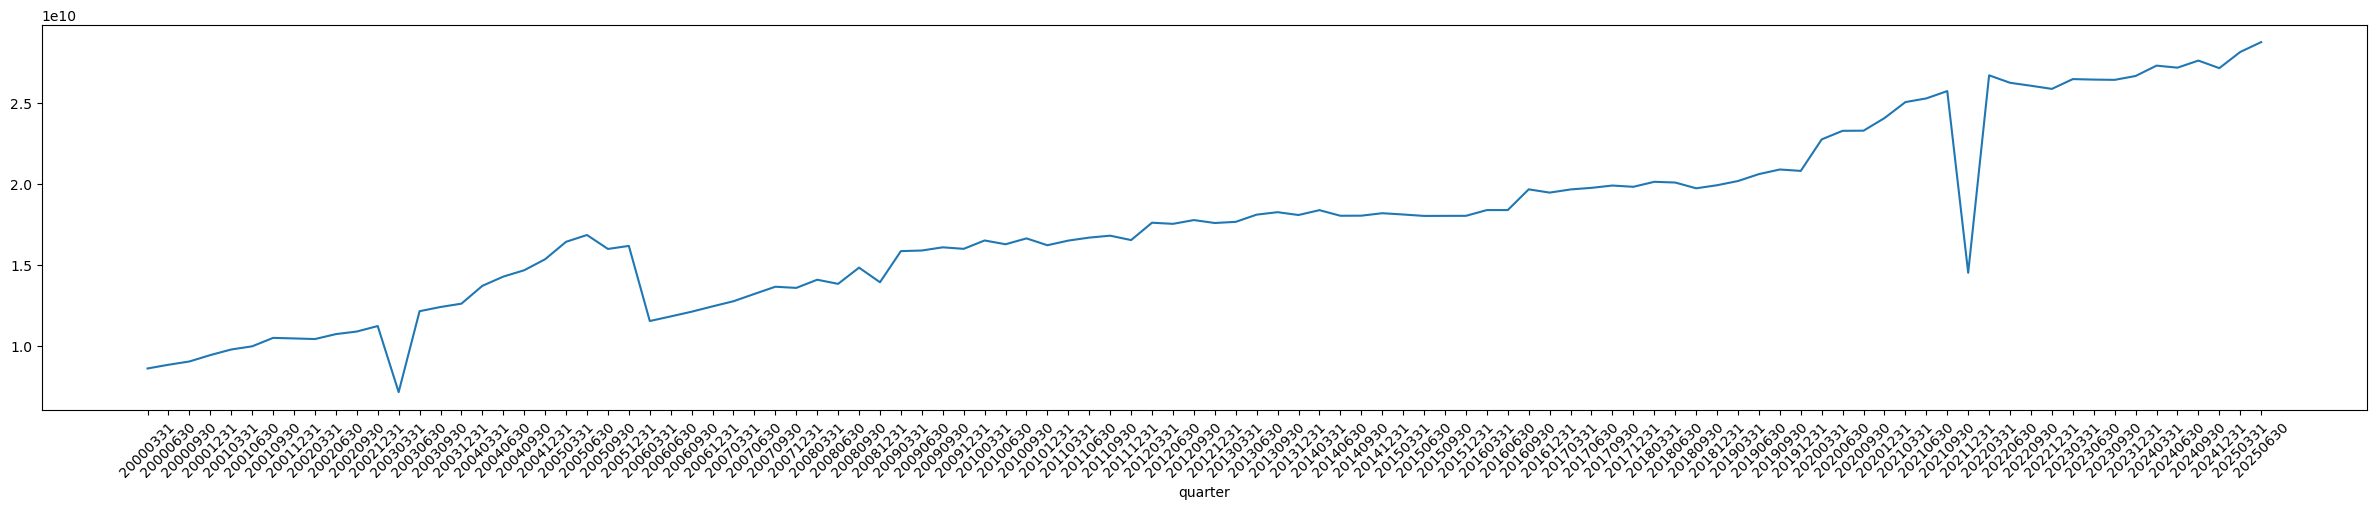

In [39]:
ax = df_9c.groupby("quarter")["TOTAL_ASSETS"].sum().plot(figsize=(30, 5))

quarters = df_9c["quarter"].unique()
tick_positions = range(len(quarters))

ax.set_xticks(tick_positions)  # more ticks
ax.set_xticklabels(quarters, rotation=45)  # show quarter labels
plt.show()

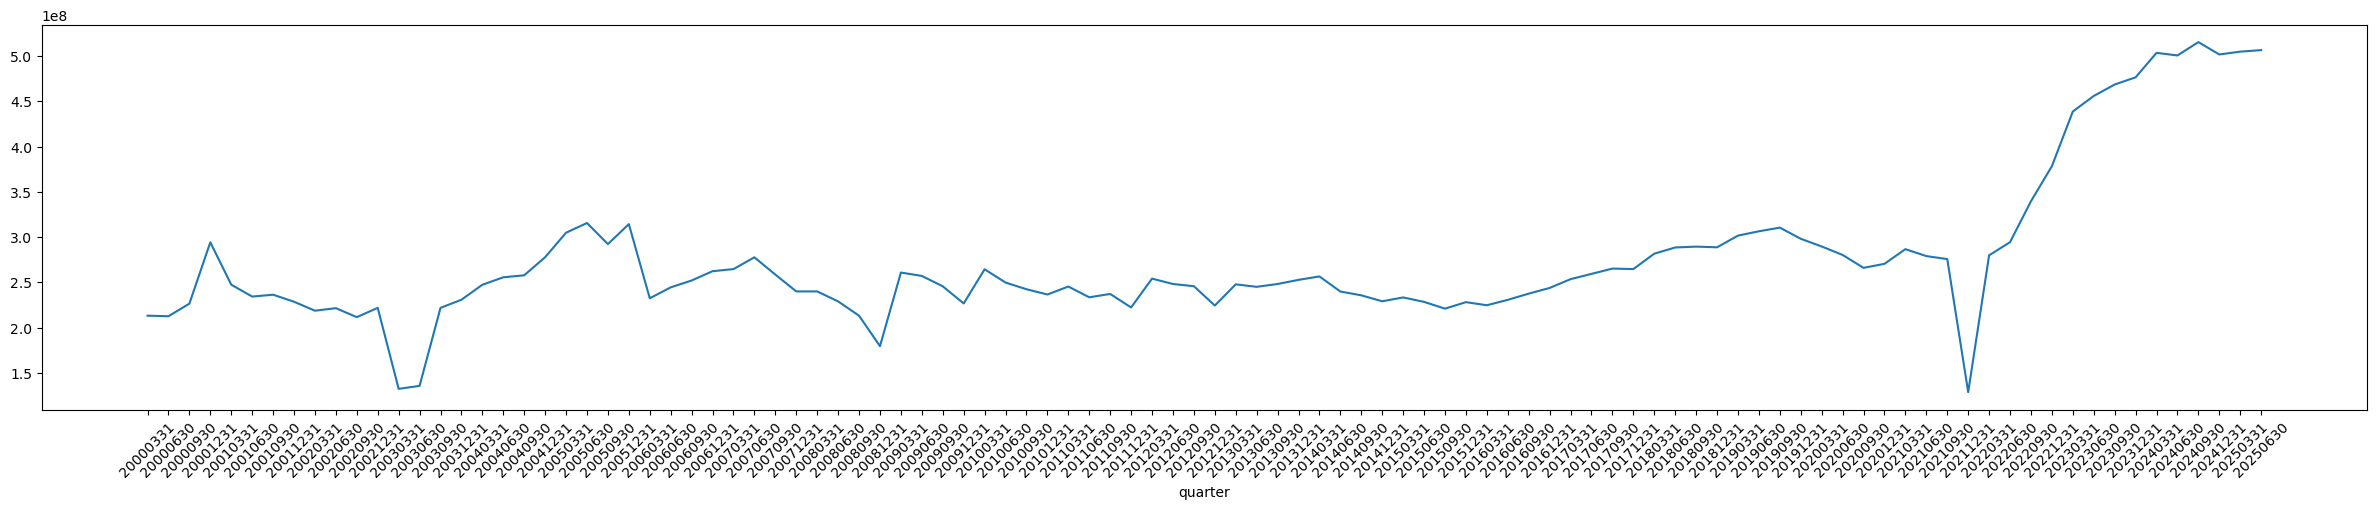

In [40]:
ax = df_9c.groupby("quarter")["REVENUE"].sum().plot(figsize=(30, 5))

quarters = df_9c["quarter"].unique()
tick_positions = range(len(quarters))

ax.set_xticks(tick_positions)  # more ticks
ax.set_xticklabels(quarters, rotation=45)  # show quarter labels
plt.show()

# 2008 crisis

In [41]:
def get_dependent_var(df_input, crisis_quarter, crisis_var, nr_quarters_before_crisis):
    # Calculate values x quarters before
    dict_target = calculate_quarterly_growth(
        df=df_input,
        target_quarter=crisis_quarter,
        nr_quarters_before=nr_quarters_before_crisis,
        value_x_quarters_before_func=value_x_quarters_before,
        value_col=crisis_var,
    )

    # Convert dict to DataFrame
    dict_target_values = list(dict_target.values())[0]
    df_target = pd.DataFrame(
        {"id": dict_target_values.keys(), crisis_var: dict_target_values.values()}
    )

    # Identify disappearing banks (NaN) and emerging banks (inf)
    missing_mask_nan = df_target[crisis_var].isna()  # disappeared
    mask_inf = np.isinf(df_target[crisis_var])  # emerging banks

    # Filter out NaN and inf for percentile calculation
    valid_mask = ~(missing_mask_nan | mask_inf)
    valid_values = df_target.loc[valid_mask, crisis_var]

    # Compute 25th and 75th percentiles on valid values only
    q25 = valid_values.quantile(0.25)
    q75 = valid_values.quantile(0.75)

    # Initialize class column
    df_target["growth_class"] = "OTHER"

    # Assign classes based on percentiles
    df_target.loc[valid_mask & (df_target[crisis_var] <= q25), "growth_class"] = (
        "BOTTOM_25"
    )
    df_target.loc[valid_mask & (df_target[crisis_var] >= q75), "growth_class"] = (
        "TOP_25"
    )

    # Assign DISAPPEARED to NaNs
    df_target.loc[missing_mask_nan, "growth_class"] = "DISAPPEARED"

    # Assign DISAPPEARED to NaNs
    df_target.loc[mask_inf, "growth_class"] = "NEW_BANKS"

    return df_target

In [42]:
def create_features_w_growth_rates(
    metrics: list,
    quarters_list: list,
    df_9c_sorted: pd.DataFrame,
    crisis_quarter: str,
    df_target_quarter: pd.DataFrame,
):

    # List to store outputs
    list_dicts_ = []

    # Loop over metrics and quarters
    for metric in metrics:
        for n_quarters in quarters_list:
            df_growth = calculate_quarterly_growth(
                df=df_9c_sorted,
                value_col=metric,
                target_quarter=crisis_quarter,
                nr_quarters_before=n_quarters,
                value_x_quarters_before_func=value_x_quarters_before,
            )
            list_dicts_.append(df_growth)

    for dict_ in list_dicts_:

        top_key = list(dict_.keys())[0]

        # Extract the inner dictionary
        growth_dict = dict_[top_key]

        # Map the values to a new column in the DataFrame
        # The new column will be named exactly as the top-level key
        df_target_quarter[top_key] = df_target_quarter["id"].map(growth_dict)
    return df_target_quarter

In [43]:
crisis_quarter = "20210930"
before_crisis_quarter = "20210331"
crisis_var = "REVENUE"
nr_quarters_before_crisis = 1

df_dependent_variable = get_dependent_var(
    df_input=df_9c,
    crisis_quarter=crisis_quarter,
    crisis_var=crisis_var,
    nr_quarters_before_crisis=nr_quarters_before_crisis,
)

df_target_quarter = df_9c[df_9c["quarter"] == before_crisis_quarter].reset_index(
    drop=True
)

In [44]:
metrics = [col for col in df_9c.columns if col.upper() == col]  # ["REVENUE"]
quarters_list = [2, 4, 8]
df_target_quarter = create_features_w_growth_rates(
    metrics=metrics,
    quarters_list=quarters_list,
    df_9c_sorted=df_9c_sorted,
    crisis_quarter=before_crisis_quarter,
    df_target_quarter=df_target_quarter,
)

C:\Users\joaof\AppData\Local\Temp\ipykernel_41064\1646198389.py:33: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_target_quarter[top_key] = df_target_quarter["id"].map(growth_dict)
C:\Users\joaof\AppData\Local\Temp\ipykernel_41064\1646198389.py:33: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_target_quarter[top_key] = df_target_quarter["id"].map(growth_dict)
C:\Users\joaof\AppData\Local\Temp\ipykernel_41064\1646198389.py:33: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.

In [45]:
# logistic_regression_model = LogisticRegression(penalty=None) # WARNING! Scikit-learn's logisticregression does the highly unusual thing of including l2 regularization by default...
decision_tree = DecisionTreeClassifier(random_state=42)

In [46]:
df_target_quarter['RATIO_COMMON_EQUITY_TIER1_CAPITAL_growth_4_quarters'].sort_values(ascending=False)

283         inf
19          inf
117         inf
225    8.575015
169    1.308230
         ...   
324         NaN
327         NaN
334         NaN
347         NaN
348         NaN
Name: RATIO_COMMON_EQUITY_TIER1_CAPITAL_growth_4_quarters, Length: 349, dtype: float64

In [47]:
df[df['id']=='']

,id,country,legal_name,quarter,REVENUE_FRY9C,REVENUE_FRY9SP,REVENUE_FRY9LP,NET_INCOME_FRY9C,NET_INCOME_FRY9SP,NET_INCOME_FRY9LP,...,RECOVERIES_FOREIGN_GOV_FRY9C,RECOVERIES_LEASE_FINANCING_FRY9C,RATIO_CAPITAL_CONSERVATION_BUFFER_FRY9C,RATIO_TIER_1_LEVERAGE_FRY9C,RATIO_TOTAL_CAPITAL_FRY9C,RATIO_TIER_1_CAPITAL_FRY9C,RATIO_COMMON_EQUITY_TIER1_CAPITAL_FRY9C,year,month,nr_quarter


In [48]:
df_target_quarter['id'].loc[348]

'5559343'

In [49]:
for col in df_target_quarter.columns[::-1]:
    if np.isinf(df_target_quarter[col].max()):
        print(col)

RATIO_COMMON_EQUITY_TIER1_CAPITAL_growth_4_quarters
RATIO_COMMON_EQUITY_TIER1_CAPITAL_growth_2_quarters
RATIO_TIER_1_CAPITAL_growth_4_quarters
RATIO_TIER_1_CAPITAL_growth_2_quarters
RATIO_TOTAL_CAPITAL_growth_4_quarters
RATIO_TOTAL_CAPITAL_growth_2_quarters
RATIO_TIER_1_LEVERAGE_growth_4_quarters
RATIO_TIER_1_LEVERAGE_growth_2_quarters
RATIO_CAPITAL_CONSERVATION_BUFFER_growth_8_quarters
RATIO_CAPITAL_CONSERVATION_BUFFER_growth_4_quarters
RATIO_CAPITAL_CONSERVATION_BUFFER_growth_2_quarters
RECOVERIES_LEASE_FINANCING_growth_8_quarters
RECOVERIES_LEASE_FINANCING_growth_4_quarters
RECOVERIES_LEASE_FINANCING_growth_2_quarters
RECOVERIES_FOREIGN_GOV_growth_8_quarters
RECOVERIES_FOREIGN_GOV_growth_4_quarters
RECOVERIES_FOREIGN_GOV_growth_2_quarters
RECOVERIES_HOUSEHOLDS_growth_8_quarters
RECOVERIES_HOUSEHOLDS_growth_4_quarters
RECOVERIES_HOUSEHOLDS_growth_2_quarters
RECOVERIES_COMMERCE_INDUSTRY_growth_8_quarters
RECOVERIES_COMMERCE_INDUSTRY_growth_4_quarters
RECOVERIES_COMMERCE_INDUSTRY_growt

TypeError: ufunc 'isinf' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

In [50]:
# Convert inf to nan
df_target_quarter_noinf = df_target_quarter.replace([np.inf, -np.inf], np.nan)

# Drop cols with only nulls
df_nonulls = df_target_quarter_noinf.dropna(axis=1, how="all")

# Drop cols with only 0s
df_nozeros = df_nonulls.loc[:, (df_nonulls != 0).any(axis=0)]

# Drop rows with at least one null
df_target_quarter_aux_clean = df_nozeros  # .dropna(axis=0, how='any')

# Drop rows with null growth class
# df_target_quarter_aux_clean = df_target_quarter_aux_clean[df_target_quarter_aux_clean['growth_class'].isna()==False].reset_index(drop=True)

# Find the banks that both have dependent_variable and independent_variables
# (we assessed scenarios where the independent_variables were not from the immediate quarter.
# with this restriction we would be able to exclude the banks that emerged during the period between independent variables quarter
# the the dependent variable quarter)
df_common_quarters = df_target_quarter_aux_clean.merge(
    df_dependent_variable.loc[:, ["id", "growth_class"]], on="id", how="inner"
).sort_values("id")

# The dependent variable corresponds to financial metrics variations. In that period some banks might have emerged. we remove those here as well
df_target_quarter_aux_2 = df_common_quarters[
    df_common_quarters["growth_class"] != "NEW_BANKS"
].reset_index(drop=True)

df_features = df_target_quarter_aux_2.loc[
    :,
    [
        col
        for col in df_target_quarter_aux_2.columns
        if col.upper() == col or "_growth_" in col
    ],
]

X = df_features.values

In [51]:
mapping = {"DISAPPEARED": 0, "BOTTOM_25": 0, "OTHER": 0, "TOP_25": 1}

Y = df_target_quarter_aux_2["growth_class"].map(mapping).values

In [52]:
# Define a pipeline: median imputation -> scaling -> logistic regression
pipeline_ = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),  # fill NaNs with column median
        ("scaler", StandardScaler()),  # standardize features
        ("logreg", decision_tree),  # logistic regression model
    ]
)


- Define cross-validation strategy
cv = KFold(n_splits=5, shuffle=True, random_state=42)

- Evaluate model with cross-validation
scores = cross_val_score(pipeline, X, Y, cv=cv, scoring='accuracy')
print("Cross-validation accuracy for each fold:", scores)
print("Mean CV accuracy:", np.mean(scores))
pd.Series(Y).value_counts()/len(Y)

## Cross validation manually adapted

In [53]:
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, precision_score, recall_score
import numpy as np
import pandas as pd

In [54]:
def k_fold_acc_precision_recall(X_train, y_train, pipeline, n_splits, threshold):
    """
    Perform K-fold evaluation using a Pipeline (imputer + scaler + logistic regression).
    Returns overall metrics and per-fold results.
    """

    kf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    fold_results = []

    for fold, (train_idx, test_idx) in enumerate(kf.split(X_train, y_train), 1):
        X_tr, X_te = X_train[train_idx], X_train[test_idx]
        y_tr, y_te = y_train[train_idx], y_train[test_idx]

        # Fit the entire pipeline on this fold
        pipeline.fit(X_tr, y_tr)

        # Predict probabilities
        y_pred_proba = pipeline.predict_proba(X_te)

        # Select threshold
        threshold_use = (
            threshold[fold - 1] if isinstance(threshold, list) else threshold
        )

        y_pred = (y_pred_proba[:, 1] > threshold_use).astype(int)

        fold_results.append(
            {
                "Fold": fold,
                "y_true": y_te,
                "y_pred": y_pred,
                "y_pred_proba": y_pred_proba,
                "Accuracy": accuracy_score(y_te, y_pred),
                "Precision": precision_score(y_te, y_pred, zero_division=0),
                "Recall": recall_score(y_te, y_pred, zero_division=0),
                "Train_vs_Test_class1": (sum(y_tr) / len(y_tr))
                / (sum(y_te) / len(y_te)),
                "share_0_vals_train": (X_tr == 0).sum().sum()
                / (X_tr.shape[0] * X_tr.shape[1]),
                "share_0_vals_test": (X_te == 0).sum().sum()
                / (X_te.shape[0] * X_te.shape[1]),
            }
        )

    # Create summary DataFrame
    df_cv_results = pd.DataFrame(
        {
            f"Fold #{r['Fold']}": [
                r["Accuracy"],
                r["Precision"],
                r["Recall"],
                r["Train_vs_Test_class1"],
                r["share_0_vals_train"],
                r["share_0_vals_test"],
            ]
            for r in fold_results
        },
        index=[
            "Accuracy",
            "Precision",
            "Recall",
            "Train_vs_Test_class1",
            "share_0_vals_train",
            "share_0_vals_test",
        ],
    )

    df_cv_results["Average"] = df_cv_results.mean(axis=1)

    return df_cv_results, fold_results

In [55]:
df_cv_results, fold_results = k_fold_acc_precision_recall(
    X_train=X, y_train=Y, pipeline=pipeline_, n_splits=10, threshold=0.25
)

In [56]:
df_cv_results

,Fold #1,Fold #2,Fold #3,Fold #4,Fold #5,Fold #6,Fold #7,Fold #8,Fold #9,Fold #10,Average
Accuracy,0.628571,0.628571,0.600000,0.685714,0.600000,0.571429,0.600000,0.647059,0.617647,0.588235,0.616723
Precision,0.300000,0.375000,0.222222,0.375000,0.142857,0.200000,0.142857,0.250000,0.222222,0.200000,0.243016
Recall,0.333333,0.666667,0.222222,0.333333,0.111111,0.222222,0.111111,0.250000,0.250000,0.250000,0.275000
Train_vs_Test_class1,0.972222,0.972222,0.972222,0.972222,0.972222,0.972222,0.972222,1.072684,1.072684,1.072684,1.002361
share_0_vals_train,0.094843,0.094697,0.095009,0.094614,0.094968,0.095176,0.094718,0.094996,0.094540,0.094270,0.094783
share_0_vals_test,0.094249,0.095547,0.092764,0.096289,0.093135,0.091280,0.095362,0.092819,0.097021,0.099503,0.094797


In [57]:
df_cv_results

,Fold #1,Fold #2,Fold #3,Fold #4,Fold #5,Fold #6,Fold #7,Fold #8,Fold #9,Fold #10,Average
Accuracy,0.628571,0.628571,0.600000,0.685714,0.600000,0.571429,0.600000,0.647059,0.617647,0.588235,0.616723
Precision,0.300000,0.375000,0.222222,0.375000,0.142857,0.200000,0.142857,0.250000,0.222222,0.200000,0.243016
Recall,0.333333,0.666667,0.222222,0.333333,0.111111,0.222222,0.111111,0.250000,0.250000,0.250000,0.275000
Train_vs_Test_class1,0.972222,0.972222,0.972222,0.972222,0.972222,0.972222,0.972222,1.072684,1.072684,1.072684,1.002361
share_0_vals_train,0.094843,0.094697,0.095009,0.094614,0.094968,0.095176,0.094718,0.094996,0.094540,0.094270,0.094783
share_0_vals_test,0.094249,0.095547,0.092764,0.096289,0.093135,0.091280,0.095362,0.092819,0.097021,0.099503,0.094797


In [58]:
df_cv_results

,Fold #1,Fold #2,Fold #3,Fold #4,Fold #5,Fold #6,Fold #7,Fold #8,Fold #9,Fold #10,Average
Accuracy,0.628571,0.628571,0.600000,0.685714,0.600000,0.571429,0.600000,0.647059,0.617647,0.588235,0.616723
Precision,0.300000,0.375000,0.222222,0.375000,0.142857,0.200000,0.142857,0.250000,0.222222,0.200000,0.243016
Recall,0.333333,0.666667,0.222222,0.333333,0.111111,0.222222,0.111111,0.250000,0.250000,0.250000,0.275000
Train_vs_Test_class1,0.972222,0.972222,0.972222,0.972222,0.972222,0.972222,0.972222,1.072684,1.072684,1.072684,1.002361
share_0_vals_train,0.094843,0.094697,0.095009,0.094614,0.094968,0.095176,0.094718,0.094996,0.094540,0.094270,0.094783
share_0_vals_test,0.094249,0.095547,0.092764,0.096289,0.093135,0.091280,0.095362,0.092819,0.097021,0.099503,0.094797


In [59]:
from sklearn.metrics import confusion_matrix

In [60]:
fold_number = 0

cm = confusion_matrix(
    y_true=fold_results[fold_number]["y_true"],
    y_pred=fold_results[fold_number]["y_pred"],
)

df_cm = pd.DataFrame(cm, columns=["0_Pred", "1_Pred"], index=["0_True", "1_True"])
df_cm

,0_Pred,1_Pred
0_True,19,7
1_True,6,3


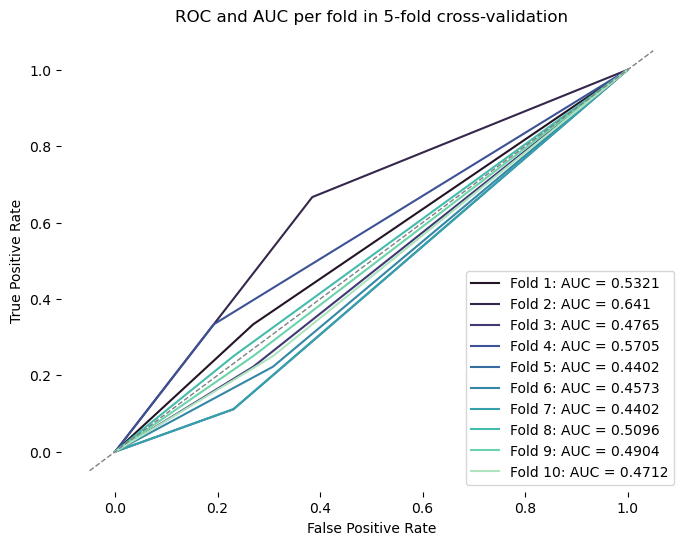

In [61]:
fig, ax = plt.subplots(figsize=(8, 6))

# Generate a color palette with as many colors as folds
palette = sns.color_palette("mako", n_colors=len(fold_results))

aucs_ = []
youden_j, youden_j_thresholds = [], []


for i, fold in enumerate(fold_results):
    # Compute ROC curve
    fpr, tpr, thresholds = roc_curve(
        y_true=fold["y_true"], y_score=fold["y_pred_proba"][:, 1]
    )  # use positive class

    # Create DataFrame for Seaborn
    df_data_plot = pd.DataFrame({"False Positive Rate": fpr, "True Positive Rate": tpr})

    aucs_.append({"Fold": fold["Fold"], "AUC": auc(fpr, tpr)})

    # Plot with specific color and label
    sns.lineplot(
        data=df_data_plot,
        x="False Positive Rate",
        y="True Positive Rate",
        errorbar=None,
        label=f"Fold {i+1}: AUC = {round(auc(fpr,tpr),4)}",
        color=palette[i],
        ax=ax,
    )

    # I will try to estimate Accuracy, Precision and Recall
    # with thresholds estimated by youden_j statistic
    youden_j_val = np.argmax(tpr - fpr)

    youden_j.append(youden_j_val)
    youden_j_thresholds.append(thresholds[youden_j_val])

xmin, xmax = ax.get_xlim()
ax.plot(
    [xmin, xmax], [xmin, xmax], linestyle="--", linewidth=1, label="y = x", color="grey"
)


ax.set_frame_on(False)

ax.set_title("ROC and AUC per fold in 5-fold cross-validation")
plt.show()

In [62]:
df_cv_results, fold_results = k_fold_acc_precision_recall(
    X_train=X, y_train=Y, pipeline=pipeline_, n_splits=10, threshold=youden_j_thresholds
)

In [63]:
df_cv_results

,Fold #1,Fold #2,Fold #3,Fold #4,Fold #5,Fold #6,Fold #7,Fold #8,Fold #9,Fold #10,Average
Accuracy,0.742857,0.742857,0.742857,0.742857,0.742857,0.742857,0.742857,0.764706,0.764706,0.764706,0.749412
Precision,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Recall,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Train_vs_Test_class1,0.972222,0.972222,0.972222,0.972222,0.972222,0.972222,0.972222,1.072684,1.072684,1.072684,1.002361
share_0_vals_train,0.094843,0.094697,0.095009,0.094614,0.094968,0.095176,0.094718,0.094996,0.094540,0.094270,0.094783
share_0_vals_test,0.094249,0.095547,0.092764,0.096289,0.093135,0.091280,0.095362,0.092819,0.097021,0.099503,0.094797


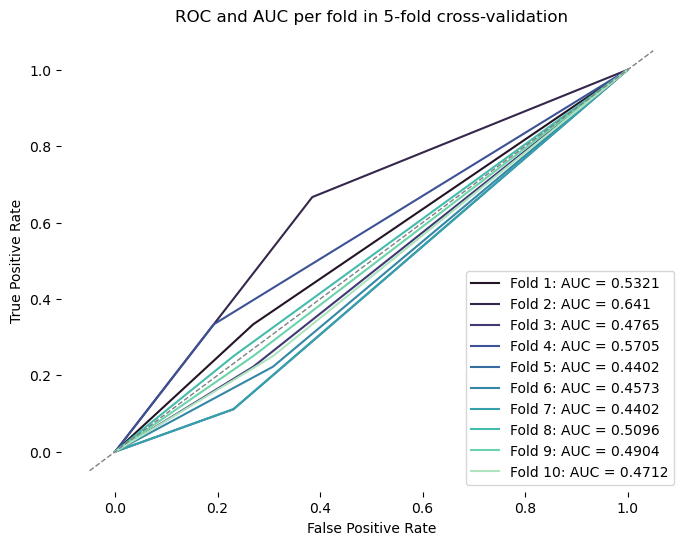

In [64]:
fig, ax = plt.subplots(figsize=(8, 6))

# Generate a color palette with as many colors as folds
palette = sns.color_palette("mako", n_colors=len(fold_results))

aucs_ = []
youden_j, youden_j_thresholds = [], []


for i, fold in enumerate(fold_results):
    # Compute ROC curve
    fpr, tpr, thresholds = roc_curve(
        y_true=fold["y_true"], y_score=fold["y_pred_proba"][:, 1]
    )  # use positive class

    # Create DataFrame for Seaborn
    df_data_plot = pd.DataFrame({"False Positive Rate": fpr, "True Positive Rate": tpr})

    aucs_.append({"Fold": fold["Fold"], "AUC": auc(fpr, tpr)})

    # Plot with specific color and label
    sns.lineplot(
        data=df_data_plot,
        x="False Positive Rate",
        y="True Positive Rate",
        errorbar=None,
        label=f"Fold {i+1}: AUC = {round(auc(fpr,tpr),4)}",
        color=palette[i],
        ax=ax,
    )

    # I will try to estimate Accuracy, Precision and Recall
    # with thresholds estimated by youden_j statistic
    youden_j_val = np.argmax(tpr - fpr)

    youden_j.append(youden_j_val)
    youden_j_thresholds.append(thresholds[youden_j_val])

xmin, xmax = ax.get_xlim()
ax.plot(
    [xmin, xmax], [xmin, xmax], linestyle="--", linewidth=1, label="y = x", color="grey"
)


ax.set_frame_on(False)

ax.set_title("ROC and AUC per fold in 5-fold cross-validation")
plt.show()

## Estimate correlations

In [48]:
cols_to_consider = [
    col for col in df_new.columns if ("CUMMULATIVE" not in col) and (col.upper() == col)
]


corr = df_new.loc[:, cols_to_consider].iloc[:, 4:].corr().stack().reset_index()
corr.columns = ["var1", "var2", "correlation"]

# Sort variable names in each pair to ignore order
corr[["var1", "var2"]] = corr[["var1", "var2"]].apply(
    lambda row: sorted(row), axis=1, result_type="expand"
)

# Drop duplicates (since now var1-var2 and var2-var1 are the same)
corr = corr.drop_duplicates()

# Remove self-correlations
corr = corr[corr["var1"] != corr["var2"]]

# Optional: filter by threshold
filtered = corr[corr["correlation"] > 0.8]

In [49]:
corr.sort_values(by="correlation")

,var1,var2,correlation
124,ASSETS_INVESTMENT_NONBANKSUBSIDIARY_EQUITY_FRY9SP,NET_INCOME_FRY9LP,-0.318648
756,ASSETS_INVESTMENT_NONBANKSUBSIDIARY_EQUITY_FRY9SP,EBT_FRY9C,-0.309697
2317,ASSETS_INVESTMENT_BANK_SUBSIDIARY_EQUITY_FRY9SP,ASSETS_INVESTMENT_HOLDINGSUBSIDIARY_EQUITY_FRY9SP,-0.185029
736,ASSETS_CASH_FRY9SP,EBT_FRY9C,-0.137070
104,ASSETS_CASH_FRY9SP,NET_INCOME_FRY9LP,-0.132359
...,...,...,...
5295,RATIO_TIER_1_LEVERAGE_FRY9C,RATIO_TOTAL_CAPITAL_FRY9C,0.998666
5366,RATIO_TIER_1_CAPITAL_FRY9C,RATIO_TOTAL_CAPITAL_FRY9C,0.998666
179,EBT_FRY9SP,NET_INCOME_BEF_UND_RUB_FRY9SP,0.998836
504,ASSETS_TOTALASSETS_FRY9LP,TOTAL_ASSETS_FRY9LP,1.000000


In [50]:
filtered.sort_values(by="correlation")

,var1,var2,correlation
2666,ASSETS_FEDERALFUNDS_RESELL_FRY9C,ASSETS_FIXEDASSETS_FRY9C,0.800185
562,ASSETS_OTHERASSETS_FRY9C,TOTAL_EQUITY_FRY9C,0.801931
5297,RATIO_COMMON_EQUITY_TIER1_CAPITAL_FRY9C,RATIO_TIER_1_LEVERAGE_FRY9C,0.801949
5437,RATIO_COMMON_EQUITY_TIER1_CAPITAL_FRY9C,RATIO_TIER_1_CAPITAL_FRY9C,0.801949
1938,ASSETS_INVESTMENTS_SUBSIDIARIES_FRY9C,ASSETS_LOANSRECEIVABLES_INVESTMENT_FRY9C,0.802535
...,...,...,...
5295,RATIO_TIER_1_LEVERAGE_FRY9C,RATIO_TOTAL_CAPITAL_FRY9C,0.998666
5366,RATIO_TIER_1_CAPITAL_FRY9C,RATIO_TOTAL_CAPITAL_FRY9C,0.998666
179,EBT_FRY9SP,NET_INCOME_BEF_UND_RUB_FRY9SP,0.998836
504,ASSETS_TOTALASSETS_FRY9LP,TOTAL_ASSETS_FRY9LP,1.000000


In [51]:
df.sort_values(by=["id", "quarter"])

,id,country,legal_name,quarter,REVENUE_FRY9C,REVENUE_FRY9SP,REVENUE_FRY9LP,NET_INCOME_FRY9C,NET_INCOME_FRY9SP,NET_INCOME_FRY9LP,...,RECOVERIES_FOREIGN_GOV_FRY9C,RECOVERIES_LEASE_FINANCING_FRY9C,RATIO_CAPITAL_CONSERVATION_BUFFER_FRY9C,RATIO_TIER_1_LEVERAGE_FRY9C,RATIO_TOTAL_CAPITAL_FRY9C,RATIO_TIER_1_CAPITAL_FRY9C,RATIO_COMMON_EQUITY_TIER1_CAPITAL_FRY9C,year,month,nr_quarter
314775,1020180,UNITED STATES,BREMER FINANCIAL CORPORATION,20000331,85127.0,0.0,10360.0,11016.0,0.0,11016.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2000,3,1
308921,1020180,UNITED STATES,BREMER FINANCIAL CORPORATION,20000630,176673.0,0.0,24304.0,22079.0,0.0,22079.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2000,6,2
306773,1020180,UNITED STATES,BREMER FINANCIAL CORPORATION,20000930,272131.0,0.0,31624.0,33754.0,0.0,33754.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2000,9,3
300917,1020180,UNITED STATES,BREMER FINANCIAL CORPORATION,20001231,368388.0,0.0,52966.0,45781.0,0.0,45781.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2000,12,4
298721,1020180,UNITED STATES,BREMER FINANCIAL CORPORATION,20010331,94175.0,0.0,13907.0,11174.0,0.0,11174.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2001,3,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3740,6006899,UNITED STATES,"WINCHESTER BANCORP, MHC",20250630,0.0,0.0,0.0,0.0,-338.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2025,6,2
3741,6007421,UNITED STATES,"WINCHESTER BANCORP, INC.",20250630,0.0,100.0,0.0,0.0,-615.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2025,6,2
3742,6010430,UNITED STATES,LINDSEY FAMILY TRUST,20250630,0.0,0.0,0.0,0.0,212.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2025,6,2
3743,6030278,UNITED STATES,FIRST SOUTHERN NATIONAL BANCSHARES INC,20250630,0.0,3000.0,0.0,0.0,11362.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2025,6,2
